# Week 12 Capstone — validated GP-UCB proposals

## tl;dr

This notebook reconstructs the post-Week-11 dataset from the immutable 88-row canonical ledger, validates the required observation counts, and generates one deterministic, bounded, non-duplicate BBO proposal per function. No Week 12 returned outputs are available, so the proposals are not observations.

## Context & Methods

The source of truth is `Results/query_output_ledger.csv` plus the pristine starter arrays under `Week_01/Function_XX/03_Data`. Each function uses a Matérn-5/2 Gaussian Process with target normalisation and UCB (`kappa=2.0`). Twenty thousand candidates are generated from a fixed per-function seed.

### Key assumptions

- The canonical ledger is correctly paired and immutable.
- All objectives are maximised over `[0, 1]^d`.
- Six-decimal duplicate checks match submission precision.

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'Results' / 'query_output_ledger.csv').is_file():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('Repository root not found')
sys.path.insert(0, str(ROOT))

from Code.data_loading import load_starter_data, append_observations
from Code.gaussian_process import fit_gaussian_process, predict_with_uncertainty
from Code.candidate_generation import make_rng, uniform_candidates
from Code.query_selection import select_query
from Code.weekly_evidence import DIMENSIONS, pairs_through_week

LEDGER = ROOT / 'Results' / 'query_output_ledger.csv'
CHECKSUM = ROOT / 'Results' / 'query_output_ledger.sha256'
expected_hash = CHECKSUM.read_text().split()[0]
actual_hash = hashlib.sha256(LEDGER.read_bytes()).hexdigest()
assert actual_hash == expected_hash
print(f'Canonical ledger checksum verified: {actual_hash}')

Canonical ledger checksum verified: 3cabc618a9b9b4a7b069309133a32850384f2f6eaad51c4264a9efb6cc5e874f


## Data

### 1. Reconstruct and validate cumulative observations

In [2]:
EXPECTED_COUNTS = {1: 21, 2: 21, 3: 26, 4: 41, 5: 31, 6: 31, 7: 41, 8: 51}
datasets = {}
validation_rows = []
for function in range(1, 9):
    X, y = load_starter_data(function, repository_root=ROOT)
    pairs = pairs_through_week(11, function)
    new_X = np.asarray([query for query, _ in pairs], dtype=float)
    new_y = np.asarray([value for _, value in pairs], dtype=float)
    X, y = append_observations(X, y, new_X, new_y)
    assert X.shape == (EXPECTED_COUNTS[function], DIMENSIONS[function])
    assert y.shape == (EXPECTED_COUNTS[function],)
    assert np.isfinite(X).all() and np.isfinite(y).all()
    assert ((X >= 0) & (X <= 1)).all()
    datasets[function] = (X, y)
    validation_rows.append({'Function': f'F{function}', 'Dimensions': X.shape[1], 'Observations': len(X), 'Best observed': float(np.max(y))})
validation = pd.DataFrame(validation_rows)
validation

,Function,Dimensions,Observations,Best observed
0,F1,2,21,7.710875e-16
1,F2,2,21,6.112052e-01
2,F3,3,26,-3.483531e-02
3,F4,4,41,-1.981075e+00
4,F5,4,31,1.465512e+03
5,F6,5,31,-7.142649e-01
6,F7,6,41,2.149905e+00
7,F8,8,51,9.939904e+00


### 2. Export validated figures by function

Each displayed panel is also written as an individual PNG under `Week_12/Function_XX/05_Figures`. Orange points are canonical ledger returns; starter observations are blue.

Matplotlib is building the font cache; this may take a moment.


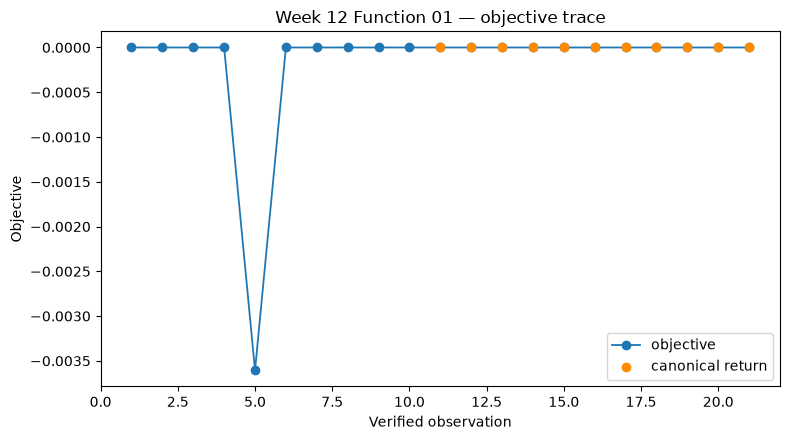

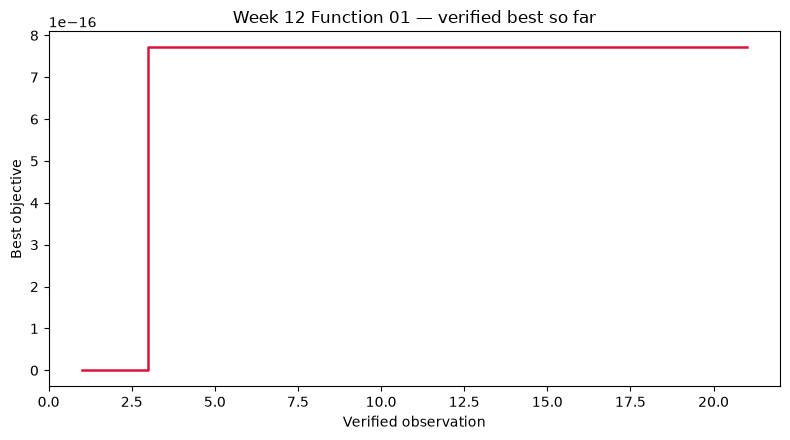

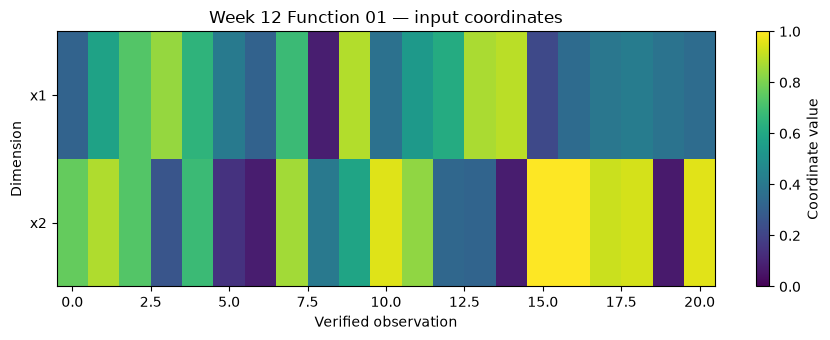

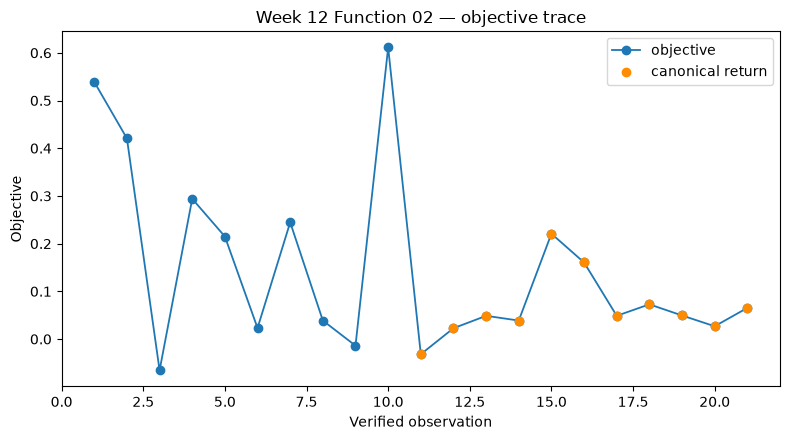

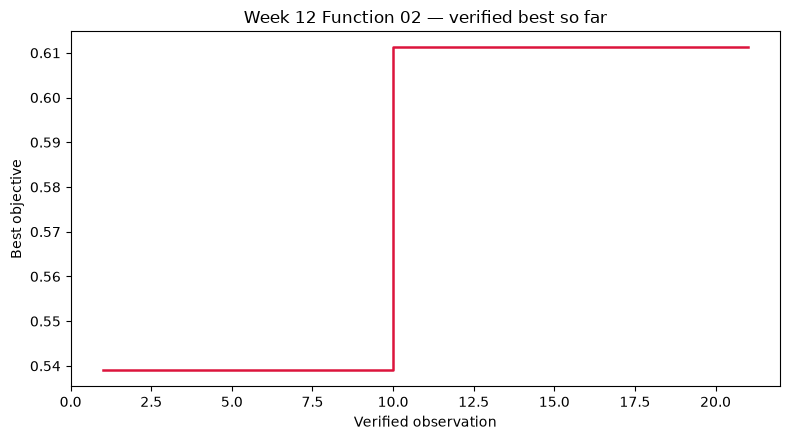

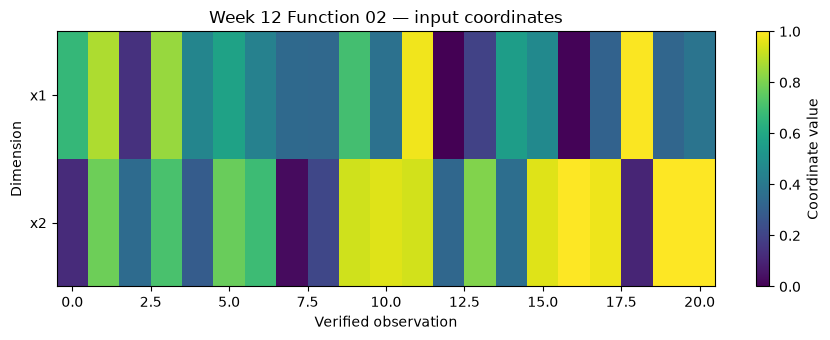

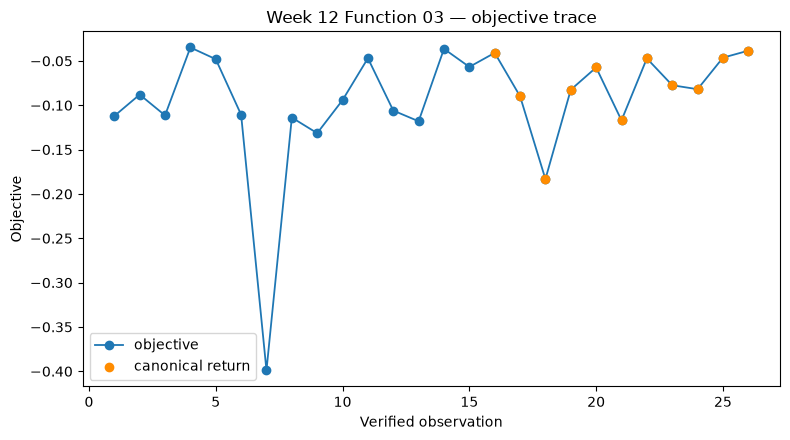

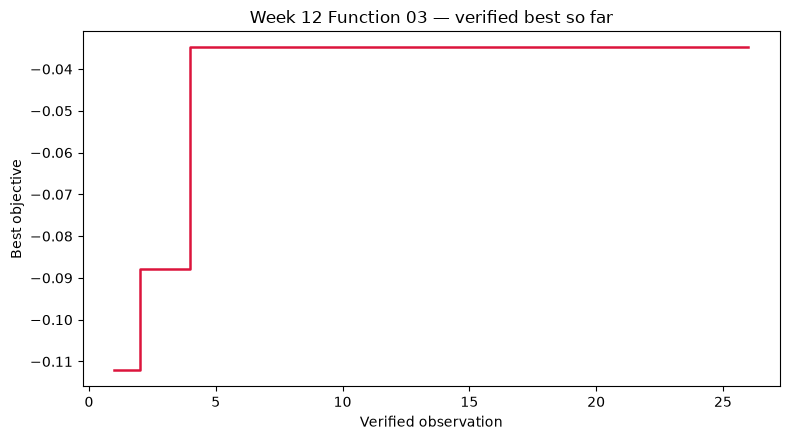

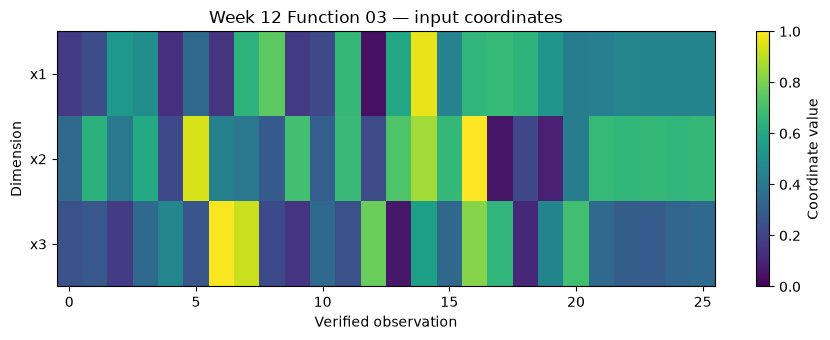

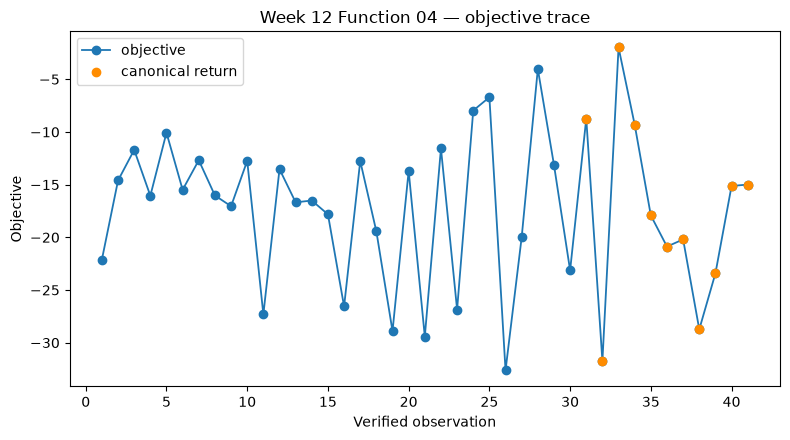

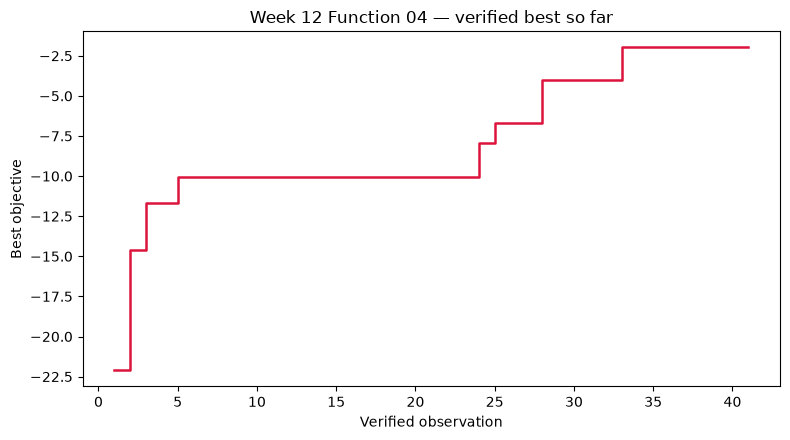

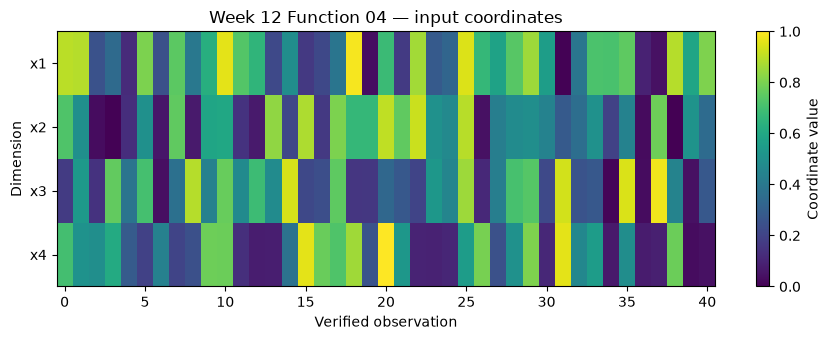

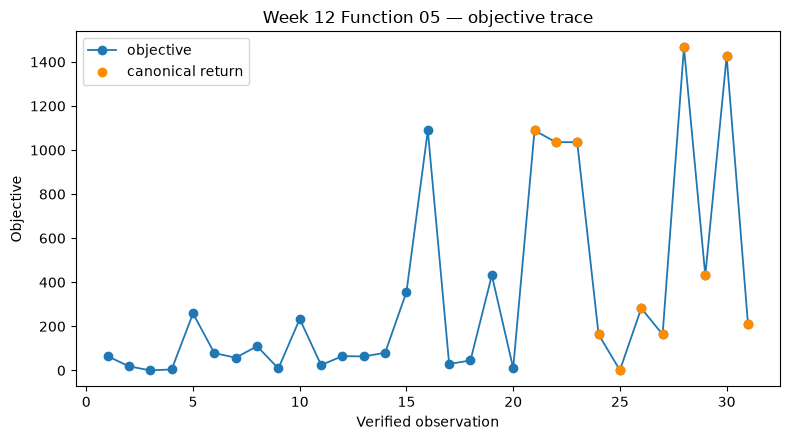

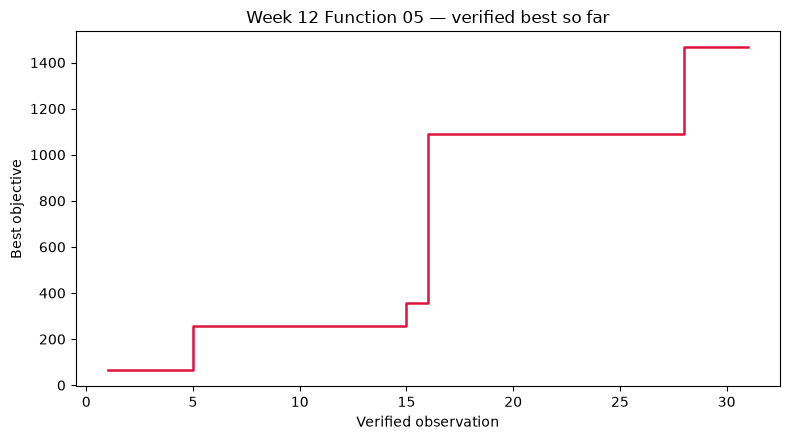

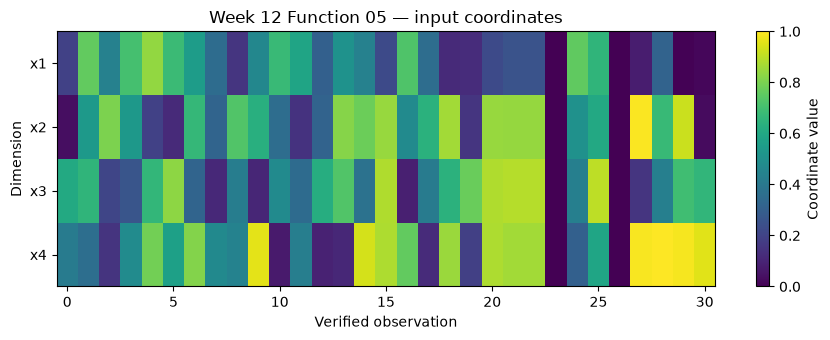

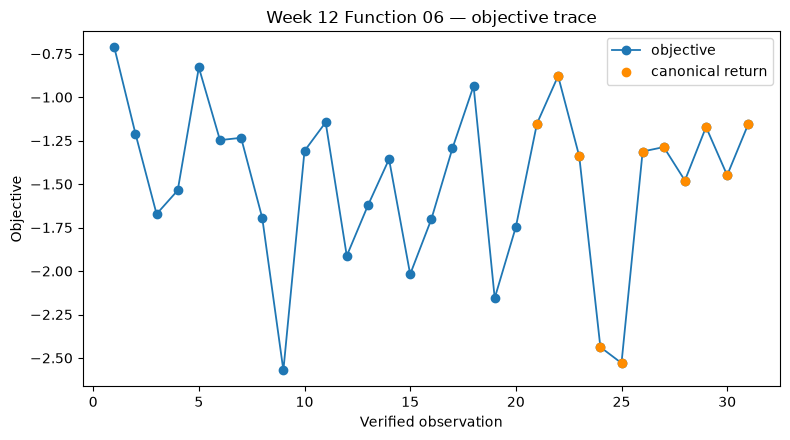

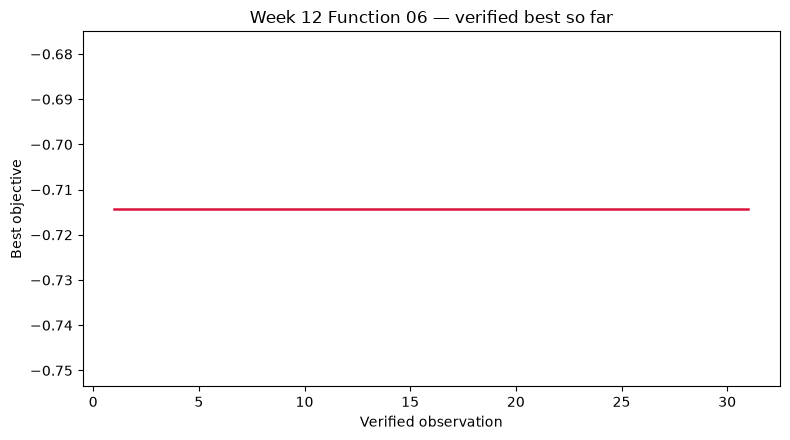

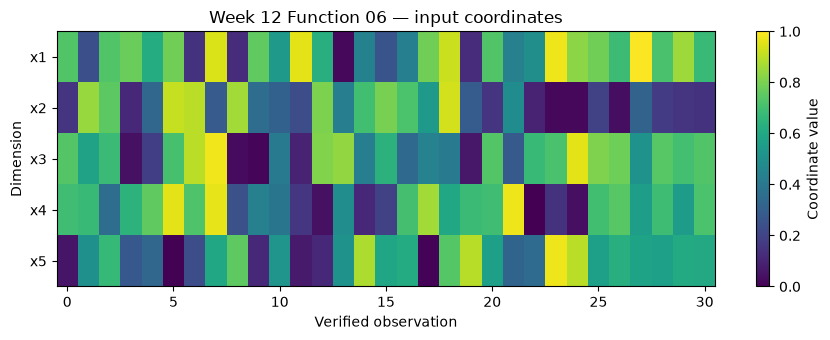

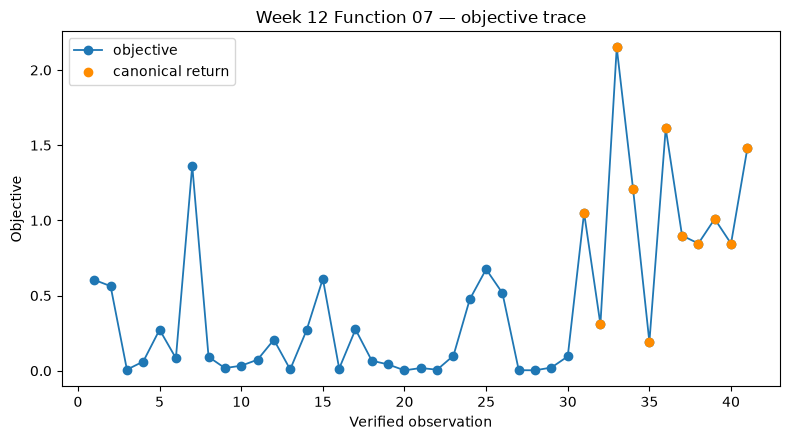

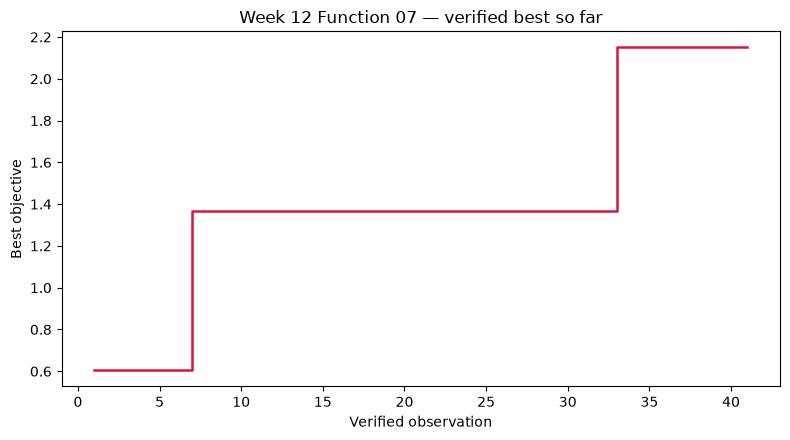

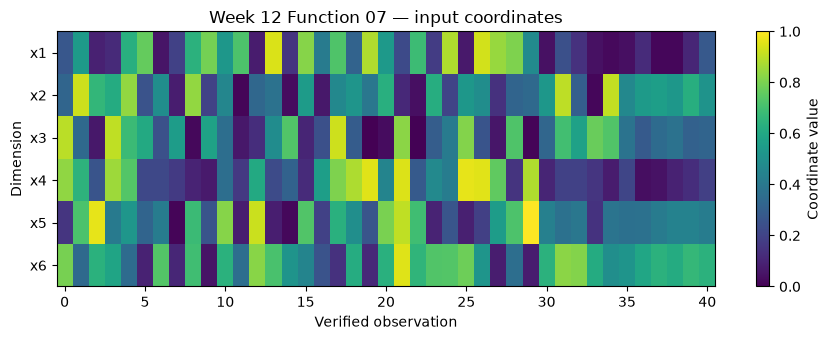

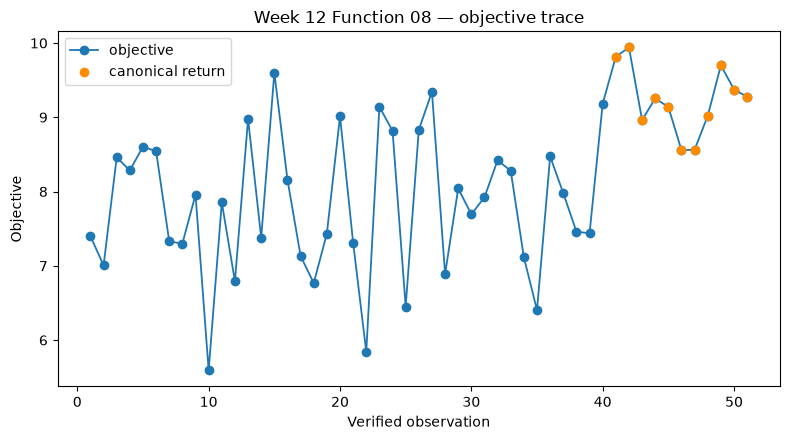

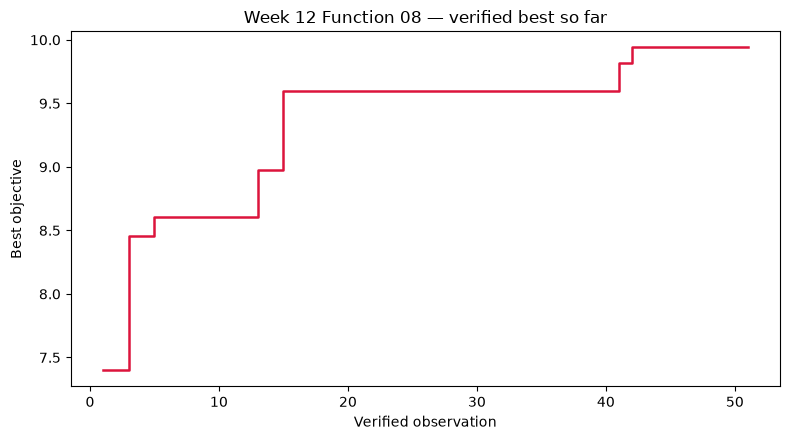

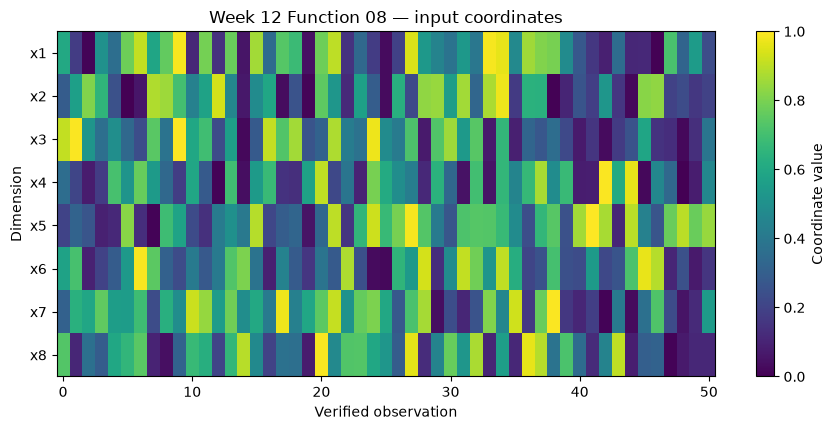

,function,figure,path
0,1,objective_trace,Week_12/Function_01/05_Figures/week_12_functio...
1,1,best_so_far,Week_12/Function_01/05_Figures/week_12_functio...
2,1,input_heatmap,Week_12/Function_01/05_Figures/week_12_functio...
3,2,objective_trace,Week_12/Function_02/05_Figures/week_12_functio...
4,2,best_so_far,Week_12/Function_02/05_Figures/week_12_functio...
5,2,input_heatmap,Week_12/Function_02/05_Figures/week_12_functio...
6,3,objective_trace,Week_12/Function_03/05_Figures/week_12_functio...
7,3,best_so_far,Week_12/Function_03/05_Figures/week_12_functio...
8,3,input_heatmap,Week_12/Function_03/05_Figures/week_12_functio...
9,4,objective_trace,Week_12/Function_04/05_Figures/week_12_functio...


In [3]:
import matplotlib.pyplot as plt
from IPython.display import display

figure_manifest = []
for function, (X, y) in datasets.items():
    starter_count = len(y) - 11
    query_index = np.arange(1, len(y) + 1)
    best_so_far = np.maximum.accumulate(y)
    figure_dir = ROOT / 'Week_12' / f'Function_{function:02d}' / '05_Figures'
    figure_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(query_index, y, marker='o', linewidth=1.3, label='objective')
    ax.scatter(query_index[starter_count:], y[starter_count:], color='darkorange', label='canonical return', zorder=3)
    ax.set(title=f'Week 12 Function {function:02d} — objective trace', xlabel='Verified observation', ylabel='Objective')
    ax.legend(); fig.tight_layout()
    path = figure_dir / f'week_12_function_{function:02d}_objective_trace.png'
    fig.savefig(path, dpi=160, bbox_inches='tight'); display(fig); plt.close(fig)
    figure_manifest.append({'function': function, 'figure': 'objective_trace', 'path': str(path.relative_to(ROOT))})

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.step(query_index, best_so_far, where='post', color='crimson', linewidth=1.8)
    ax.set(title=f'Week 12 Function {function:02d} — verified best so far', xlabel='Verified observation', ylabel='Best objective')
    fig.tight_layout()
    path = figure_dir / f'week_12_function_{function:02d}_best_so_far.png'
    fig.savefig(path, dpi=160, bbox_inches='tight'); display(fig); plt.close(fig)
    figure_manifest.append({'function': function, 'figure': 'best_so_far', 'path': str(path.relative_to(ROOT))})

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.55 * X.shape[1])))
    image = ax.imshow(X.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set(title=f'Week 12 Function {function:02d} — input coordinates', xlabel='Verified observation', ylabel='Dimension')
    ax.set_yticks(range(X.shape[1]), [f'x{i + 1}' for i in range(X.shape[1])])
    fig.colorbar(image, ax=ax, label='Coordinate value'); fig.tight_layout()
    path = figure_dir / f'week_12_function_{function:02d}_input_heatmap.png'
    fig.savefig(path, dpi=160, bbox_inches='tight'); display(fig); plt.close(fig)
    figure_manifest.append({'function': function, 'figure': 'input_heatmap', 'path': str(path.relative_to(ROOT))})

figure_manifest = pd.DataFrame(figure_manifest)
figure_manifest

## Results

### 3. Fit GP-UCB models and select new queries

In [4]:
proposal_rows = []
for function, (X, y) in datasets.items():
    model = fit_gaussian_process(X, y, optimizer_restarts=3, random_state=4200 + function)
    candidates = uniform_candidates(DIMENSIONS[function], 20_000, rng=make_rng(4200 + function))
    mean, std = predict_with_uncertainty(model, candidates)
    selected = select_query(candidates, X, mean, std, method='ucb', kappa=2.0, decimals=6)
    duplicate = np.any(np.all(np.round(X, 6) == selected.query, axis=1))
    assert not duplicate and ((selected.query >= 0) & (selected.query <= 1)).all()
    proposal_rows.append({
        'week': 12, 'function': function, 'dimensions': DIMENSIONS[function],
        'observation_count': len(X), 'query': json.dumps(selected.query.tolist(), separators=(',', ':')),
        'submission_query': '-'.join(f'{value:.6f}' for value in selected.query),
        'predicted_mean': selected.predicted_mean, 'predictive_std': selected.predicted_std,
        'ucb_score': selected.acquisition, 'kernel': str(model.kernel_),
        'candidate_count': 20_000, 'kappa': 2.0, 'random_seed': 4200 + function,
        'duplicate_at_6dp': duplicate, 'status': 'proposal_only_return_unavailable'
    })
proposals = pd.DataFrame(proposal_rows)
proposals[['function', 'observation_count', 'submission_query', 'predictive_std', 'ucb_score']]

/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value

/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/private/tmp/week12-notebook-deps/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value

,function,observation_count,submission_query,predictive_std,ucb_score
0,1,21,0.985530-0.508068,0.000892,0.001804
1,2,21,0.698570-0.005967,0.088871,0.759961
2,3,26,0.972188-0.997743-0.391105,0.071284,0.108940
3,4,41,0.370439-0.382409-0.425133-0.390888,0.544867,-0.262830
4,5,31,0.874157-0.993155-0.978150-0.979670,307.051221,2261.962117
5,6,31,0.004840-0.033276-0.614036-0.992733-0.018278,0.436965,0.061916
6,7,41,0.087492-0.296104-0.894458-0.260860-0.263170-0...,0.214878,2.380431
7,8,51,0.047423-0.249478-0.266938-0.124120-0.525139-0...,0.259604,10.292949


### 4. Save the proposal ledger and submission file

In [5]:
proposal_path = ROOT / 'Results' / 'bbo_query_ledger.csv'
proposals.to_csv(proposal_path, index=False)
query_path = ROOT / 'Week_12' / '01_Queries' / 'week_12_query_points.txt'
query_path.write_text(''.join(f"Function_{row.function}:{row.submission_query}\n" for row in proposals.itertuples()), encoding='utf-8')
print(query_path.read_text())

Function_1:0.985530-0.508068
Function_2:0.698570-0.005967
Function_3:0.972188-0.997743-0.391105
Function_4:0.370439-0.382409-0.425133-0.390888
Function_5:0.874157-0.993155-0.978150-0.979670
Function_6:0.004840-0.033276-0.614036-0.992733-0.018278
Function_7:0.087492-0.296104-0.894458-0.260860-0.263170-0.806628
Function_8:0.047423-0.249478-0.266938-0.124120-0.525139-0.625310-0.069902-0.963405



## Takeaways

- The canonical post-Week-11 counts are `21, 21, 26, 41, 31, 31, 41, 51`.
- Every proposed point is finite, within bounds, correctly dimensioned, and distinct from observed points at six-decimal precision.
- These are Week 12 submission proposals only. They must not be appended to the query/output ledger until authoritative returned outputs are available.